In [2]:
# @title Package
from natsort import natsorted
import numpy as np
import seaborn as sns
import pandas as pd

import matplotlib.pyplot as plt
import os

import torch
import torch.nn as nn
import torch.nn.functional as F
import scipy as sp
import scipy.signal as signal
import torchaudio
import math
from sklearn import svm

import torchvision
import torchvision.transforms as transforms
import torchaudio.models as audio_models

from torch.utils.data import DataLoader
from torch.utils.data import TensorDataset

import time

lib_dir = '/content/drive/MyDrive/Project/BrainRegionId/Project44/Code'
os.chdir(lib_dir)
print('library directory: ' + lib_dir)
from modules.networks_clf import *
from modules.signal import spectro_norm, lfp_spectro
from modules.data import *
from modules.metrics import accu_fun

library directory: /content/drive/MyDrive/Project/BrainRegionId/Project44/Code


In [3]:
# @title Load device
dtype = torch.float
# Check whether GPU is available
if torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')

!nvidia-smi -L


GPU 0: Tesla T4 (UUID: GPU-a2b41cde-8426-5f4c-e798-4fd4a84affac)


In [4]:
# Set the signal parameters
spectro_args = {
    'nfft':800,
    'power':1,
    'LFP_bound':[0, 500],
    'MUA_bound':[500, 2000],
    'spectro_img':[224, 28],
    'LFP_img':[56 * 4, 28],
    'MUA_img':[0, 28],
    'sampling_lfp':2500,
    'sampling_mua':5000,
    'Log':False,
}

# dict_dir = '/content/drive/MyDrive/Project/BrainRegionId/Project37/Data/dat'
# acronym_list = acronym_list_gen(dict_dir)

In [5]:
# @title Load data
key = 'stimOff_times'
file_dir = '/content/drive/MyDrive/Project/BrainRegionId/Project43/Data/dat/completed/'
# torch.save(brain_signal_lfp, '/content/drive/MyDrive/Project/BrainRegionId/Project43/Result/brain_signal_lfp/brain_signal_lfp.pt')
brain_signal_lfp = torch.load('/content/drive/MyDrive/Project/BrainRegionId/Project43/Result/brain_signal_lfp/brain_signal_lfp.pt')
list_dict = torch.load(file_dir + '/list_dict.pt')
# list_dict_acronym_selec = torch.load(file_dir + '/list_dict_acronym_selec.pt')
brain_region_index = list_dict['brain_region_index']
brain_region_index_Cosmos = list_dict['brain_region_index_Cosmos']
coordinate_list = list_dict['coordinate_list']

id_community_mapping = torch.load('/content/drive/MyDrive/Project/BrainRegionId/Project44/Result/id_community_mapping.pt')
brain_region_index_AnyNet = torch.tensor(id_community_mapping['AnyNet'][brain_region_index], dtype=torch.long)
brain_region_index_ViT = torch.tensor(id_community_mapping['ViT'][brain_region_index], dtype=torch.long)
brain_region_index_RNN = torch.tensor(id_community_mapping['RNN'][brain_region_index], dtype=torch.long)

subject_od_ind = torch.load(f'/content/drive/MyDrive/Project/BrainRegionId/Project44/Model/Allen/subject_od_ind_Allen_{key}{0}.pt')
subject_od_list = torch.load(f'/content/drive/MyDrive/Project/BrainRegionId/Project44/Model/Allen/subject_od_list_Allen_{key}{0}.pt')
train_ind, valid_ind, test_ind, test_subject_ind = dat_ind_gen(list_dict, subject_od_ind, key)

In [8]:
def iter_gen(train_ind, valid_ind, test_ind, brain_signal_lfp, brain_region_index0, coordinate_list):

    data_test = TensorDataset(brain_signal_lfp[test_ind,:], brain_region_index0[test_ind], coordinate_list[test_ind])

    test_iter = DataLoader(data_test, batch_size=128, shuffle=True)

    return test_iter

In [9]:
test_iter_AnyNet = iter_gen(train_ind, valid_ind, test_ind, brain_signal_lfp, brain_region_index_AnyNet, coordinate_list)
test_iter_ViT = iter_gen(train_ind, valid_ind, test_ind, brain_signal_lfp, brain_region_index_ViT, coordinate_list)
test_iter_RNN = iter_gen(train_ind, valid_ind, test_ind, brain_signal_lfp, brain_region_index_RNN, coordinate_list)

In [12]:
ind = 0
model_dir = '/content/drive/MyDrive/Project/BrainRegionId/Project44/Model/Community'
key = 'stimOff_times'

Classifier_AnyNet = torch.load(model_dir + f'/AnyNet_L_AllenCommunity_{key}_{ind}.pth').to(device)
Classifier_ViT = torch.load(model_dir + f'/ViT_L_AllenCommunity_{key}_{ind}.pth').to(device)
Classifier_RNN = torch.load(model_dir + f'/RNN_L_AllenCommunity_{key}_{ind}.pth').to(device)

In [13]:
train_args = {
    'overfitting_thres':0.60,
    'lr':5e-4,
    'norm':True,
    'temp':[True, True],
    'epochs':50,

}


In [14]:
model_type = []
acu_test = []
iter_list = [test_iter_AnyNet, test_iter_ViT, test_iter_RNN]
Classifier_name = ['AnyNet', 'ViT', 'RNN']
for Classifier_ii, Classifier in enumerate([Classifier_AnyNet, Classifier_ViT, Classifier_RNN]):
    Classifier.eval()
    for x_test1, y_test, coordinate_test in iter_list[Classifier_ii]:
        if Classifier_name[Classifier_ii] == 'RNN':
            x_test = lfp_spectro(x_test1, spectro_args, train_args)
            y_test = y_test.to(device)
            py_test = Classifier(x_test.to(device).squeeze(1).permute(0, 2, 1))
            del x_test, x_test1
            acu_test.append(accu_fun(py_test, y_test))
            model_type.append(Classifier_name[Classifier_ii])

        elif Classifier_name[Classifier_ii] in ['Chance', 'Linear']:
            x_test = lfp_spectro(x_test1, spectro_args, train_args)
            y_test = y_test.to(device)
            py_test = Classifier(x_test.to(device).squeeze(1).flatten(start_dim=1))
            del x_test, x_test1
            acu_test.append(accu_fun(py_test, y_test))
            model_type.append(Classifier_name[Classifier_ii])

        else:
            x_test = lfp_spectro(x_test1, spectro_args, train_args)
            y_test = y_test.to(device)
            py_test = Classifier(x_test.to(device))
            del x_test, x_test1
            acu_test.append(accu_fun(py_test, y_test))
            model_type.append(Classifier_name[Classifier_ii])
    print(Classifier_ii)


acu = pd.DataFrame({
    'acu_test': np.array(acu_test),
    'model_type': model_type,
})

0
1
2


In [15]:
color_list = sns.color_palette('colorblind')
# color_list_define = []
# color_list_define.append(color_list[-2])
# color_list_define.append(color_list[-3])
# for ii in range(0, 5):
#     color_list_define.append(color_list[ii])

<ipython-input-22-cc3b05b1c224>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  g = sns.barplot(
<ipython-input-22-cc3b05b1c224>:4: UserWarning: The palette list has more values (10) than needed (3), which may not be intended.
  g = sns.barplot(


Text(0.5, 1.0, 'Community')

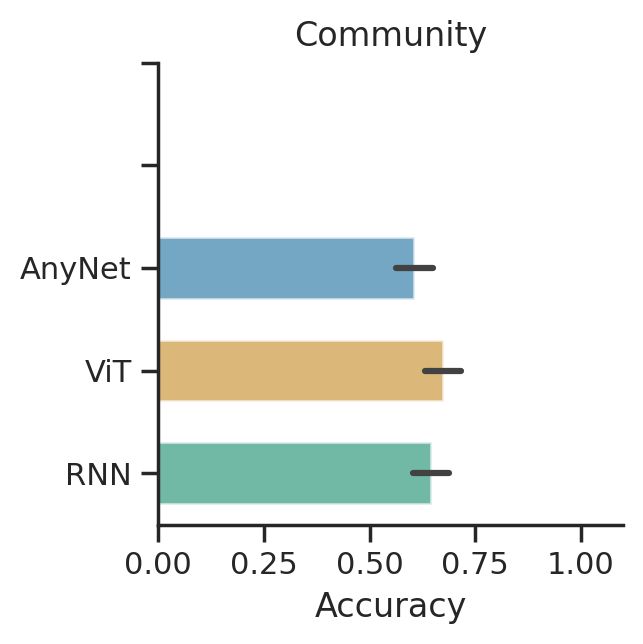

In [22]:
sns.set_theme(style='ticks')

plt.figure(figsize=(3, 3), dpi=200)
g = sns.barplot(
    data=acu,
    x='acu_test', y='model_type',
    errorbar='sd', width=0.6, palette=color_list, alpha=.6
)
plt.xlim([0, 1.1])
plt.ylabel('')
plt.xlabel('Accuracy')
plt.yticks([-2, -1, 0, 1, 2])
sns.despine()
plt.title(f'Community')

In [ ]:
from google.colab import runtime
runtime.unassign()